### 📊 Experiments Results

🔹 1. Imports

In [1]:
import json
import pandas as pd
from pathlib import Path

🔹 2. Função de interpretação

In [2]:
def interpret(value, metric):
    if metric == "accuracy":
        if value > 0.8: return "🔥 Muito bom"
        elif value > 0.6: return "👍 Ok"
        else: return "⚠️ Baixo"
    
    if metric == "proxy_score":
        if value > 0.75: return "🔥 Forte"
        elif value > 0.5: return "👍 Médio"
        else: return "⚠️ Fraco"

🔹 3. Load + processamento

In [3]:
def load_and_process(path):
    data = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                data.append(json.loads(line))
            except json.JSONDecodeError:
                continue

    rows = []

    for item in data:
        if not isinstance(item, dict):
            print("Item estranho:", item)
            continue

        pred = item.get("prediction", "").upper()
        gold = item.get("gold_label", "").upper()

        # 🔥 CORREÇÃO IMPORTANTE AQUI
        steps = item.get("pipeline", {}).get("steps", [])

        evidence_counts = [len(s.get("evidence", [])) for s in steps]

        avg_evidence = sum(evidence_counts) / len(evidence_counts) if evidence_counts else 0

        rows.append({
            "claim_id": item.get("claim_id"),
            "prediction": pred,
            "label": gold,
            "correct": pred == gold,
            "num_steps": len(steps),
            "avg_evidence_per_step": avg_evidence,
        })

    df = pd.DataFrame(rows)

    accuracy = df["correct"].mean()
    evidence_score = df["avg_evidence_per_step"].mean()

    proxy_score = 0.7 * accuracy + 0.3 * min(evidence_score / 5.0, 1.0)

    metrics = {
        "accuracy": accuracy,
        "proxy_score": proxy_score
    }

    return df, metrics

🔹 4. Paths

In [4]:
paths = {
    "baseline": [
        "../outputs/averitec_original_pipeline/llama3.1-8b/averitec_dev.jsonl"
    ],
    "iterative": [
        "../outputs/averitec_iterative_pipeline/llama3.1-8b/averitec_dev.jsonl"
    ]
}

🔹 5. Carregamento geral

In [5]:
dfs = {}
results = {}

for pipeline, file_list in paths.items():
    dfs[pipeline] = []
    results[pipeline] = []

    for path in file_list:
        df, metrics = load_and_process(path)

        run_name = Path(path).parent.name
        df["run"] = run_name

        dfs[pipeline].append(df)
        results[pipeline].append(metrics)

🔹 6. Concatenar tudo

In [6]:
dfs_concat = {
    k: pd.concat(v, ignore_index=True)
    for k, v in dfs.items()
}

🔹 7. Print por pipeline

In [7]:
from pathlib import Path
from sklearn.metrics import classification_report

import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

def print_pipeline_summary(name, df):
    run_name = Path(path).parent.name
    dataset_name = Path(path).name

    df["run"] = run_name
    df["dataset"] = dataset_name

    for run, df_run in df.groupby("run"):

        accuracy = df_run["correct"].mean()
        evidence_score = df_run["avg_evidence_per_step"].mean()
        

        df_errors = df_run[~df_run["correct"]]

        print("=" * 50)
        print(f"📌 PIPELINE: {name.upper()} - {run}")
        #print(f"📂 ARQUIVO: {run}")
        print(f"📂 DATASET: {df_run['dataset'].iloc[0]}")
        print("\n")
        print('🎯 Accuracy:', round(accuracy, 2), '->', interpret(accuracy, 'accuracy'))
        print("\n")

        print("📊 Total samples:", len(df_run))
        print("✅ Correct predictions:", df_run["correct"].sum())
        print("❌ Errors:", len(df_errors))
        print("=" * 50)
        #print(classification_report(df["label"], df["prediction"]))
        #print("📊 Per-class accuracy:")
        #print(df.groupby("label")["correct"].mean())

for name in dfs_concat:
    print_pipeline_summary(name, dfs_concat[name])

📌 PIPELINE: BASELINE - llama3.1-8b
📂 DATASET: averitec_dev.jsonl


🎯 Accuracy: 0.5 -> ⚠️ Baixo


📊 Total samples: 500
✅ Correct predictions: 251
❌ Errors: 249
📌 PIPELINE: ITERATIVE - llama3.1-8b
📂 DATASET: averitec_dev.jsonl


🎯 Accuracy: 0.61 -> 👍 Ok


📊 Total samples: 500
✅ Correct predictions: 304
❌ Errors: 196


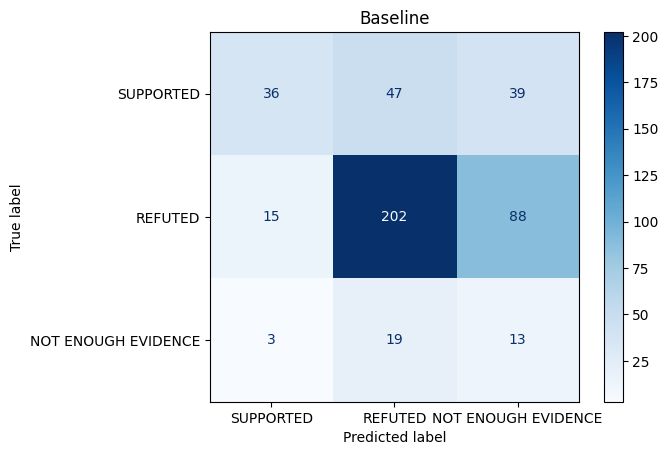

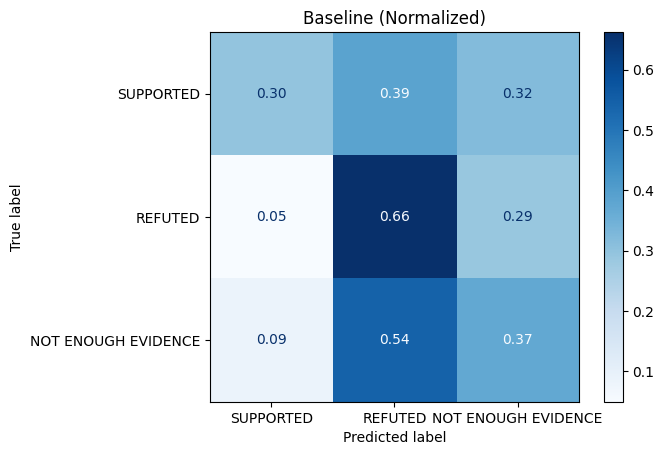

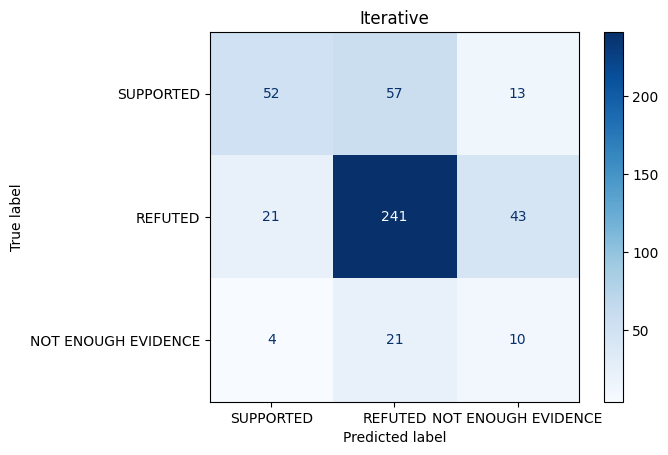

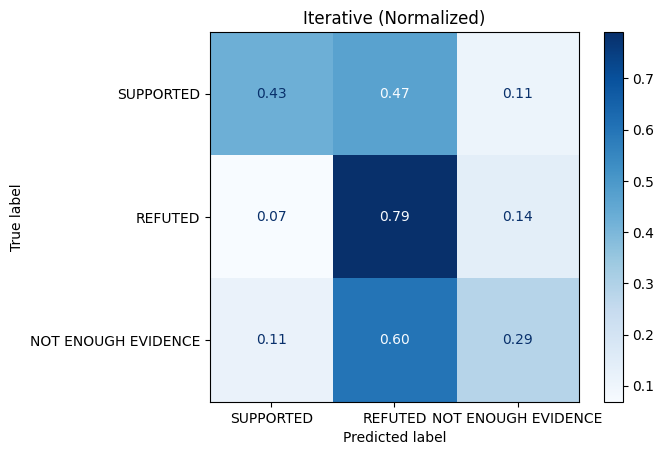

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

LABELS = ["SUPPORTED", "REFUTED", "NOT ENOUGH EVIDENCE"]

def plot_confusion_matrix(df, title, normalize=False):
    cm = confusion_matrix(df["label"], df["prediction"], labels=LABELS)

    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=LABELS
    )

    disp.plot(cmap=plt.cm.Blues, values_format=".2f" if normalize else "d")
    plt.title(title + (" (Normalized)" if normalize else ""))
    plt.show()

plot_confusion_matrix(dfs_concat["baseline"], "Baseline")
plot_confusion_matrix(dfs_concat["baseline"], "Baseline", normalize=True)

plot_confusion_matrix(dfs_concat["iterative"], "Iterative")
plot_confusion_matrix(dfs_concat["iterative"], "Iterative", normalize=True)